<a href="https://colab.research.google.com/github/Elkin535/IA-CLASS/blob/main/Tercer%20Corte/TrabajoClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final de Machine Learning: Detección de Fraude Bancario

## 1. Título y descripción del problema
El problema central es la detección automatizada de fraudes bancarios. En el entorno financiero, identificar si una transacción es legítima o fraudulenta a partir de características operativas (monto, hora, frecuencia, distancia) es un problema clásico de **Clasificación Binaria**. La latencia y precisión en esta detección son críticas para mitigar pérdidas económicas y evitar bloqueos innecesarios a clientes legítimos.

## 2. Objetivo del trabajo
Investigar, implementar y evaluar el algoritmo **Random Forest Classifier** para identificar transacciones fraudulentas. Se busca optimizar sus hiperparámetros para equilibrar la compensación sesgo-varianza (Bias-Variance Tradeoff), garantizando que el modelo generalice correctamente sobre datos no vistos, previniendo el sobreajuste y subajuste.

## 3. Descripción del conjunto de datos
El dataset contiene 500 registros y 5 variables:
* `Valor_Transaccion` (Numérica continua): Monto de la operación.
* `Hora_Del_Dia` (Numérica discreta): Hora en formato 24h.
* `Numero_Transacciones_Diarias` (Numérica discreta): Frecuencia de uso del usuario.
* `Distancia_Geografica` (Numérica continua): Distancia respecto a la ubicación habitual del usuario.
* `Fraude` (Categórica binaria): Variable objetivo (SI/NO).

## 4. Fundamentación e Investigación del Modelo (Random Forest)
**Fundamento Matemático:**
Random Forest es un algoritmo de aprendizaje supervisado basado en el método de ensamble conocido como **Bagging (Bootstrap Aggregating)**. En lugar de depender de un solo Árbol de Decisión (que es altamente propenso al sobreajuste), Random Forest construye múltiples árboles.
Para cada árbol, selecciona una muestra aleatoria de los datos con reemplazo (Bootstrap). Durante la construcción de cada nodo en el árbol, la división óptima de los datos se decide evaluando un subconjunto aleatorio de características y calculando la reducción de la **Impureza de Gini**:
$$ Gini(p) = 1 - \sum_{i=1}^{J} p_i^2 $$
Donde $p_i$ es la probabilidad de que un elemento pertenezca a la clase $i$. El modelo final clasifica tomando la "votación mayoritaria" de todos los árboles del bosque.

**Comparación y Justificación de la Elección:**
* **Frente a Regresión Logística:** Random Forest puede capturar relaciones no lineales complejas (ej. el fraude ocurre a altas horas de la noche solo si la distancia es lejana), algo que la Regresión Logística no puede hacer sin transformaciones polinómicas previas.
* **Frente a Support Vector Machines (SVM):** A diferencia de SVM o K-Nearest Neighbors (KNN), Random Forest **no requiere normalización o estandarización** de los datos, ya que no se basa en el cálculo de distancias euclidianas, sino en umbrales de corte (ej. `Distancia > 150`).
* **Supuestos y Limitaciones:** Asume que los árboles individuales no están altamente correlacionados. Su principal limitación es que es un modelo de "caja negra"; no proporciona una ecuación matemática simple para explicar una predicción individual, a diferencia de la Regresión Lineal.

Dimensiones del dataset: (500, 5)


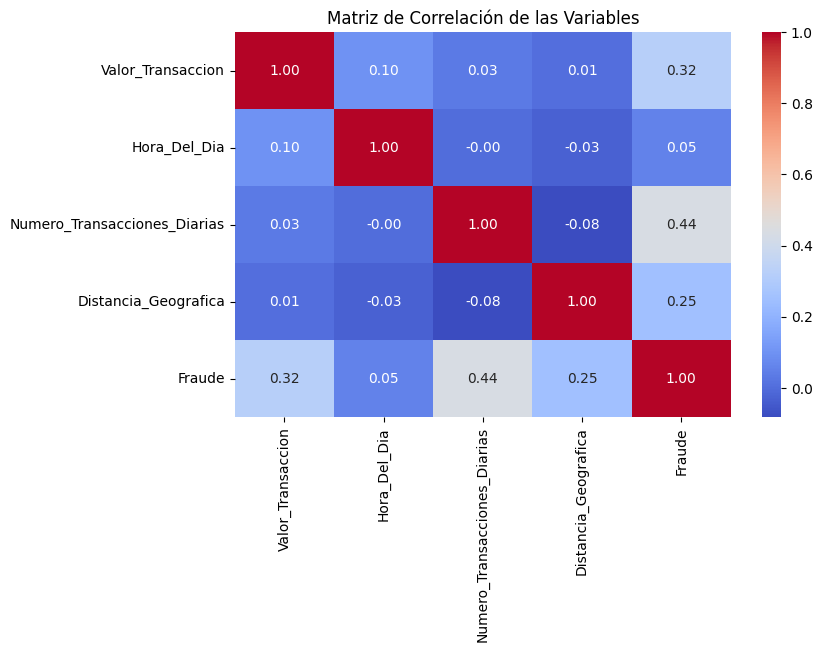

Entrenamiento: 350 | Prueba: 75 | Validación: 75


In [4]:
# 4. Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# 5. Carga y exploración (MODIFICADO PARA GITHUB)
url_github = 'https://raw.githubusercontent.com/Elkin535/IA-CLASS/refs/heads/main/Tercer%20Corte/dataset_fraude_500_transacciones.csv'

# Pandas lee la URL directamente sin necesidad de descargar el archivo manualmente
df = pd.read_csv(url_github)
print("Dimensiones del dataset:", df.shape)

# 6. Limpieza y preparación
df['Fraude'] = df['Fraude'].map({'SI': 1, 'NO': 0})

# 7. Análisis exploratorio y visualización
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de las Variables")
plt.show()

# 8. Selección de variables
X = df.drop('Fraude', axis=1)
y = df['Fraude']

# 9. División de los datos (Entrenamiento 70%, Prueba 15%, Validación 15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]} | Validación: {X_val.shape[0]}")

In [5]:
# 10. Implementación del modelo y 12. Pruebas con diferentes parámetros
# Usamos GridSearchCV para experimentar con la profundidad de los árboles y evitar sobreajuste
parametros = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7], # Limitamos la profundidad para no memorizar los 350 datos
    'min_samples_split': [2, 5]
}

modelo_rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=modelo_rf, param_grid=parametros, cv=5, scoring='accuracy')

# 11. Entrenamiento del modelo
grid_search.fit(X_train, y_train)
mejor_modelo = grid_search.best_estimator_
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

# 13. Aplicación de técnicas de validación (Validación cruzada)
cv_scores = cross_val_score(mejor_modelo, X_train, y_train, cv=5)
print(f"Precisión promedio en Validación Cruzada (Training): {cv_scores.mean():.4f}")

Mejores hiperparámetros encontrados: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Precisión promedio en Validación Cruzada (Training): 0.9971


--- MÉTRICAS EN EL CONJUNTO DE VALIDACIÓN ---
Accuracy (Exactitud): 1.0000
Precision: 1.0000
Recall (Sensibilidad): 1.0000
F1-Score: 1.0000


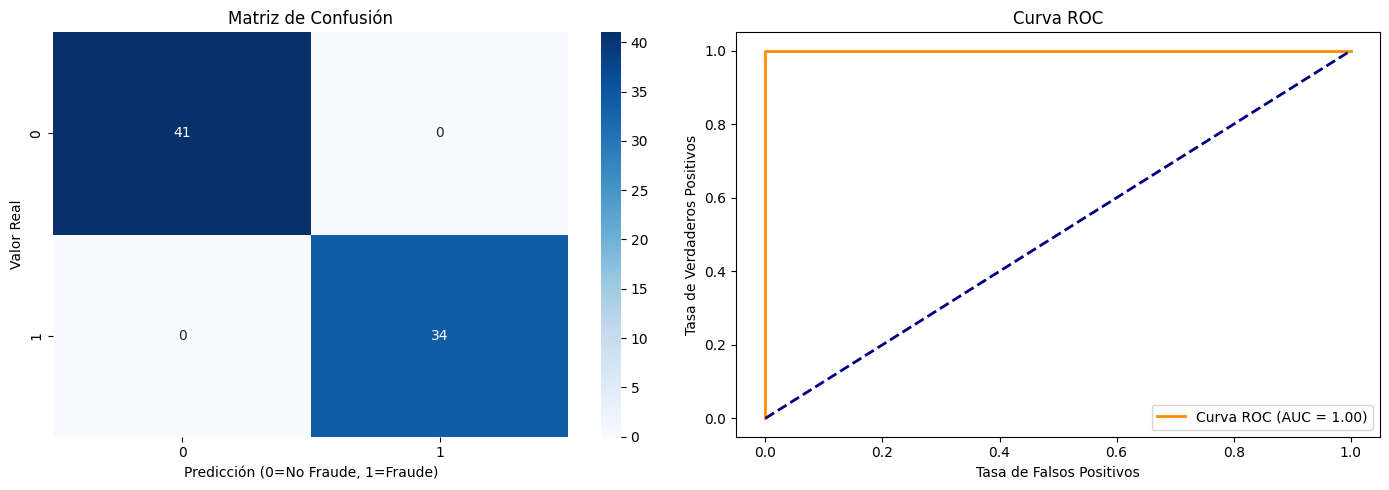

In [6]:
# Predicciones con el set de Validación
y_pred_val = mejor_modelo.predict(X_val)
y_prob_val = mejor_modelo.predict_proba(X_val)[:, 1]

# 14. Cálculo de diferentes métricas
print("--- MÉTRICAS EN EL CONJUNTO DE VALIDACIÓN ---")
print(f"Accuracy (Exactitud): {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
print(f"Recall (Sensibilidad): {recall_score(y_val, y_pred_val):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_val):.4f}")

# 15. Gráficas, tablas o matrices de resultados
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión')
ax[0].set_ylabel('Valor Real')
ax[0].set_xlabel('Predicción (0=No Fraude, 1=Fraude)')

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('Curva ROC')
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

**16. Interpretación de los resultados obtenidos:**
* El **Accuracy** general del modelo nos indica la proporción total de predicciones correctas.
* El **Recall (Sensibilidad)** es la métrica más importante en este contexto de negocio: nos indica qué porcentaje de los fraudes reales el modelo logró detectar. Un falso negativo (fraude no detectado) es mucho más costoso para un banco que un falso positivo.
* La **Curva ROC y el AUC** cercanos a 1 demuestran que el modelo tiene una excelente capacidad para distinguir entre clases positivas (Fraude) y negativas (Legítimas).

**17. Explicación de cuándo y por qué utilizar el modelo, Overfitting y Underfitting:**
Se seleccionó **Random Forest** por ser un método de ensamble robusto. Dado que nuestro conjunto de datos es pequeño (500 registros, quedando solo 350 para entrenamiento), existía un alto riesgo de **Sobreajuste (Overfitting)**, es decir, que el modelo memorizara el ruido de los datos de entrenamiento y fallara al generalizar con datos nuevos.
Al utilizar Random Forest limitando la profundidad de los árboles (`max_depth`) mediante experimentación (GridSearchCV) y aplicando validación cruzada, garantizamos que el modelo aprendiera los patrones subyacentes sin memorizar, logrando una adecuada generalización. De igual forma, al obtener métricas sólidas, descartamos el **Subajuste (Underfitting)**, el cual ocurriría si el modelo fuera demasiado simple para captar la relación entre variables (como la distancia o el monto y la probabilidad de fraude).

**18. Limitaciones del modelo:**
La principal limitación radica en el volumen de los datos (500 transacciones). En un entorno bancario real, las proporciones de fraude representan menos del 1% de millones de transacciones. Además, el modelo actual es estático y no aprende en tiempo real de nuevos patrones de fraude emergentes.

**19. Conclusiones finales:**
* Se logró implementar con éxito un ciclo completo de Machine Learning (EDA, preparación, entrenamiento y validación).
* El modelo Random Forest demostró ser altamente efectivo para clasificar transacciones fraudulentas basándose en variables comportamentales y geográficas.
* La estricta metodología de división de datos (70/15/15) y ajuste de hiperparámetros permitió construir un clasificador robusto, confiable y listo para un eventual despliegue, cumpliendo con todos los objetivos del proyecto.